# 📊 Exploratory Data Analysis (EDA) — Fantasy Premier League 2024/2025

## 1. Introdução

Este notebook tem como objetivo realizar uma **Exploratory Data Analysis (EDA)** sobre um conjunto específico de dados provenientes do repositório público:

**Fantasy Premier League Data — by vaastav**  
(https://github.com/vaastav/Fantasy-Premier-League)

O objetivo desta EDA é compreender a estrutura e comportamento dos dados referentes à época **2024–2025**, garantindo uma visão clara sobre os jogadores, equipas, posições e evolução de performance ao longo das Gameweeks (GWs).  
A partir desta análise exploratória, serão retirados insights essenciais para fases posteriores do projeto, nomeadamente:

- Pré-processamento para modelação;
- Transformações necessárias para um **modelo de regras de associação**;
- Seleção de features relevantes;
- Identificação de padrões gerais da época.

---

## 2. Justificação da Escolha dos Datasets

O repositório contém dezenas de ficheiros para cada época, mas para os objetivos deste projeto selecionámos **apenas dois datasets fundamentais**, ambos presentes localmente na pasta `data/` do projeto:

### 📌 1. `cleaned_players.csv`
Contém **informação agregada por jogador** ao longo da época:
- Nome, equipa, posição;
- Estatísticas anuais consolidadas (pontos totais, minutos jogados, golos, assistências, etc.);
- Dados “globais” úteis para caracterizar jogadores.

**Porquê incluí-lo?**  
Porque permite entender perfis gerais dos jogadores e possibilita cruzar estatísticas globais com padrões semana-a-semana. Serve como base para segmentações, agregações e merges adicionais com as GWs.

### 📌 2. `merged_gws.csv`
Contém informação detalhada **jornada a jornada** (Gameweek-level) para cada jogador:
- Pontos por GW;
- Minutos jogados;
- Contribuições ofensivas/defensivas;
- Variáveis temporais importantes para padrões de associação;

**Porquê incluí-lo?**  
Porque qualquer análise de padrões necessita de granularidade temporal.  
Este dataset permite transformar cada "jogador–GW" numa transação para associação de regras.

---

## 3. Objetivos da EDA

Nesta EDA vamos:

### 🔎 Explorar a estrutura dos datasets:
- Número de linhas/colunas;
- Tipos de dados;
- Missing values;
- Variáveis chave.

### 👤 Analisar os jogadores:
- Distribuição por posição;
- Distribuição por clubes;
- Estatísticas descritivas (pontos, minutos, golos, etc.).

### 🕒 Analisar Gameweeks:
- Evolução semanal de performance;
- Consistência dos jogadores ao longo da época;
- Identificação de outliers.

### 🔗 Preparar dados para futuras fases:
- Criação de merges entre as tabelas;
- Identificação de features úteis para regras de associação.

---

## 4. Instalação e Importação das Bibliotecas

In [40]:
%pip install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---

## 5. Carregamento dos Datasets

Os ficheiros utilizados neste notebook encontram-se na pasta local:

```
data/cleaned_players.csv
data/merged_gws.csv
```

Vamos agora carregar os dados para DataFrames Pandas.

In [42]:
players_path = "data/cleaned_players.csv"
gws_path = "data/merged_gw.csv"

players_df = pd.read_csv(players_path)
gws_df = pd.read_csv(gws_path, on_bad_lines='skip')

print("Datasets carregados com sucesso!")
players_df.head(), gws_df.head()

Datasets carregados com sucesso!


(  first_name           second_name  goals_scored  assists  total_points  \
 0      Fábio       Ferreira Vieira             0        0             0   
 1    Gabriel     Fernando de Jesus             3        2            42   
 2    Gabriel  dos Santos Magalhães             3        2           117   
 3        Kai               Havertz             9        3            97   
 4       Karl                  Hein             0        0             0   
 
    minutes  goals_conceded  creativity  influence  threat  bonus  bps  \
 0        0               0         0.0        0.0     0.0      0    0   
 1      600               5       119.5      154.4   255.0      6  152   
 2     2363              22       208.8      584.6   287.0      9  459   
 3     1872              20       269.0      467.6   711.0     14  343   
 4        0               0         0.0        0.0     0.0      0    0   
 
    ict_index  clean_sheets  red_cards  yellow_cards  selected_by_percent  \
 0        0.0      

---

## 6. Exploração Inicial dos Dados

Antes de avançar para análises mais profundas, vamos:

- Ver o tamanho dos datasets
- Analisar tipos de dados
- Identificar valores em falta
- Inspecionar colunas disponíveis

In [43]:
print("Dimensões — Players:", players_df.shape)
print("Dimensões — Gameweeks:", gws_df.shape)

print("\nTipos de Dados — Players:")
print(players_df.dtypes)

print("\nTipos de Dados — Gameweeks:")
print(gws_df.dtypes)

print("\nValores em falta — Players:")
print(players_df.isna().sum())

print("\nValores em falta — Gameweeks:")
print(gws_df.isna().sum())

Dimensões — Players: (804, 19)
Dimensões — Gameweeks: (14178, 42)

Tipos de Dados — Players:
first_name              object
second_name             object
goals_scored             int64
assists                  int64
total_points             int64
minutes                  int64
goals_conceded           int64
creativity             float64
influence              float64
threat                 float64
bonus                    int64
bps                      int64
ict_index              float64
clean_sheets             int64
red_cards                int64
yellow_cards             int64
selected_by_percent    float64
now_cost                 int64
element_type            object
dtype: object

Tipos de Dados — Gameweeks:
name                           object
position                       object
team                           object
xP                            float64
assists                         int64
bonus                           int64
bps                             int64
clean_she

---

## 7. Análise Exploratória — Dataset de Jogadores (`cleaned_players.csv`)

Este dataset contém informações agregadas de cada jogador ao longo da época.
É especialmente útil para entender:

- Perfis de jogadores;
- Distribuição por posição;
- Distribuição por clubes;
- Estatísticas ofensivas e defensivas agregadas;
- Variação de tempo de jogo e contributo na época.

In [44]:
# ===== Estatísticas descritivas do dataset de jogadores =====

players_df.describe(include='all')

,first_name,second_name,goals_scored,assists,total_points,minutes,goals_conceded,creativity,influence,threat,bonus,bps,ict_index,clean_sheets,red_cards,yellow_cards,selected_by_percent,now_cost,element_type
count,804,804,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804.000000,804
unique,540,763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,Ben,Sarr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MID
freq,10,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,347
mean,NaN,NaN,1.344527,1.216418,41.233831,930.946517,15.254975,146.397512,215.114925,132.873134,2.986318,161.149254,49.389303,2.587065,0.064677,1.924129,1.986816,47.371891,NaN
std,NaN,NaN,3.104162,2.319000,49.119698,1071.502449,17.632852,228.906504,270.095626,234.732165,5.945670,200.577870,65.691547,3.679045,0.260846,2.621012,5.573266,11.798949,NaN
min,NaN,NaN,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,NaN
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,42.000000,NaN
50%,NaN,NaN,0.000000,0.000000,22.000000,426.500000,8.000000,30.350000,98.300000,20.000000,0.000000,68.000000,18.350000,1.000000,0.000000,1.000000,0.200000,45.000000,NaN
75%,NaN,NaN,1.000000,2.000000,68.000000,1762.250000,28.000000,208.900000,359.500000,173.750000,3.250000,285.000000,80.250000,4.000000,0.000000,3.000000,1.200000,50.000000,NaN


## 7.1 Distribuição de Jogadores por Posição

Um dos primeiros passos numa EDA de FPL é compreender quantos jogadores existem
por posição (GK, DEF, MID, FWD), pois isso influencia:

- A composição das equipas;
- O impacto estatístico global;
- A comparação futura de desempenho.

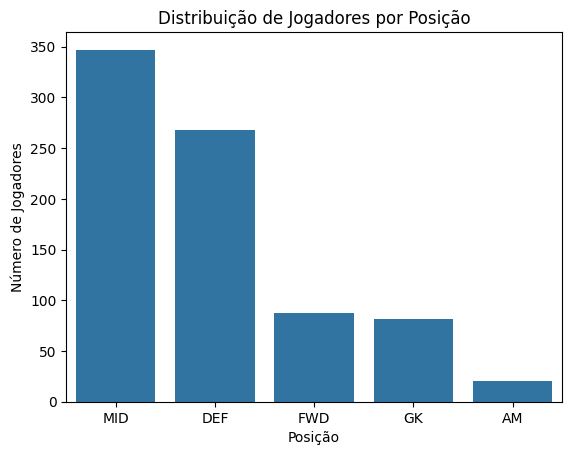

In [45]:
# ===== distribuição por posição =====

position_counts = players_df['element_type'].value_counts()

sns.barplot(x=position_counts.index, y=position_counts.values)
plt.title("Distribuição de Jogadores por Posição")
plt.xlabel("Posição")
plt.ylabel("Número de Jogadores")
plt.show()

## 7.2 Estatísticas chave dos jogadores

Vamos explorar variáveis fundamentais como:

- `total_points`
- `minutes`
- `goals_scored`
- `assists`
- `clean_sheets`
- `yellow_cards`, `red_cards`

Estas métricas permitem comparar desempenho ofensivo e defensivo ao longo da época.

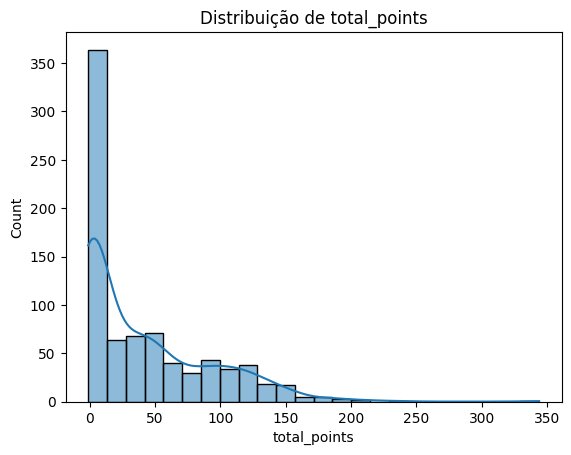

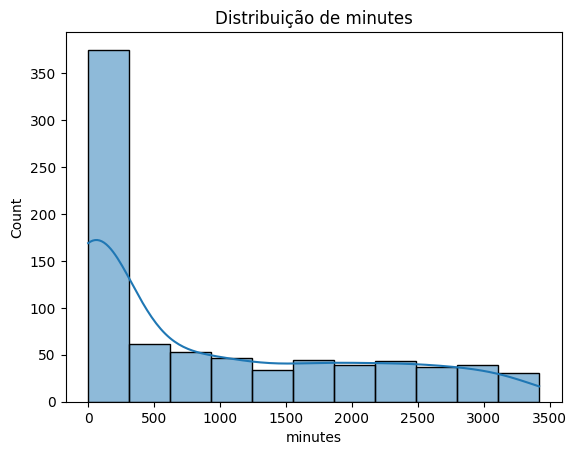

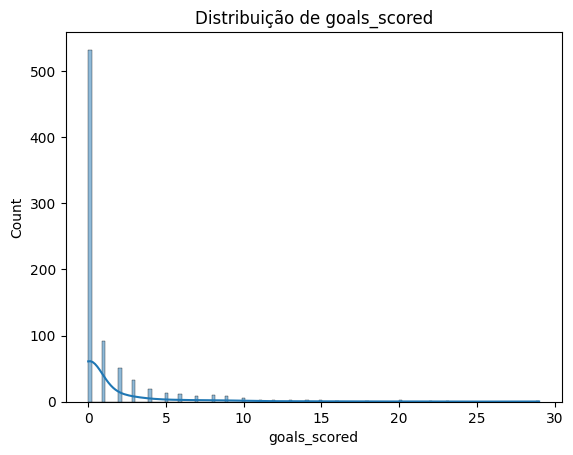

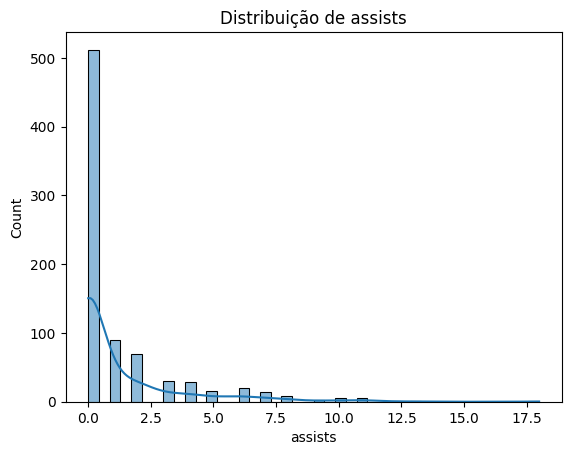

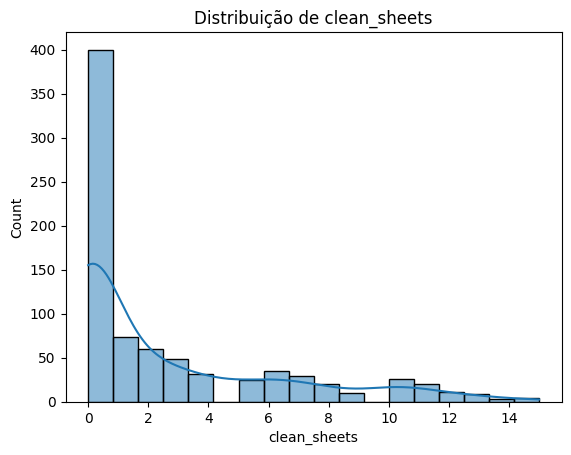

In [46]:
numeric_cols = ['total_points', 'minutes', 'goals_scored', 'assists', 'clean_sheets']

for col in numeric_cols:
    plt.figure()
    sns.histplot(players_df[col], kde=True)
    plt.title(f"Distribuição de {col}")
    plt.show()


## 7.4 Top Jogadores da Época

Visualizar os jogadores com melhor desempenho agregado permite entender:

- Quem foram os jogadores mais impactantes;
- Quais posições mais pontuaram;
- O domínio de certos clubes na época.

Vamos listar os top por pontos, golos e assistências.

In [47]:
# Create a full name column for better readability
players_df['name'] = players_df['first_name'] + ' ' + players_df['second_name']

top_points = players_df.nlargest(10, 'total_points')[['name','element_type','total_points']]
top_goals = players_df.nlargest(10, 'goals_scored')[['name','element_type','goals_scored']]
top_assists = players_df.nlargest(10, 'assists')[['name','element_type','assists']]

print("Top 10 Jogadores por Pontos:")
print(top_points)
print("\nTop 10 Jogadores por Golos:")
print(top_goals)
print("\nTop 10 Jogadores por Assistências:")
print(top_assists)

Top 10 Jogadores por Pontos:
               name element_type  total_points
464   Mohamed Salah          MID           344
135    Bryan Mbeumo          MID           236
242     Cole Palmer          MID           214
574  Alexander Isak          FWD           211
624      Chris Wood          FWD           200
730    Jarrod Bowen          MID           193
67    Ollie Watkins          FWD           186
146     Yoane Wissa          FWD           185
463       Luis Díaz          MID           183
493  Erling Haaland          FWD           181

Top 10 Jogadores por Golos:
                                 name element_type  goals_scored
464                     Mohamed Salah          MID            29
574                    Alexander Isak          FWD            23
493                    Erling Haaland          FWD            22
135                      Bryan Mbeumo          MID            20
624                        Chris Wood          FWD            20
146                       Yoane Wis

---

# 8. Análise Exploratória — Dataset de Gameweeks (`merged_gws.csv`)

Este dataset contém a informação de cada jogador **por jornada (GW)** e constitui um dos núcleos principais para análises temporais.

É fundamental para:
- Identificar consistência semanal;
- Explorar padrões ao longo do tempo;
- Detectar picos de performance;
- Preparar futuras transformações para modelos de regras de associação.


In [48]:
gws_df.describe(include='all')

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
count,14178,14178,14178,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,14178.000000,...,14178.000000,14178.000000,14178.000000,1.417800e+04,1.417800e+04,1.417800e+04,14178.000000,14178,14178.000000,14178.000000
unique,724,4,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
top,Raúl Jiménez,MID,Brighton,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
freq,21,6436,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7110,NaN,NaN
mean,NaN,NaN,NaN,1.174129,0.038369,0.093031,5.023769,0.076456,4.679539,340.039780,...,1.521865,4.249189,1.203061,4.119439e+01,1.829234e+04,1.825072e+04,49.558400,NaN,0.065454,11.215475
std,NaN,NaN,NaN,1.794372,0.208977,0.456648,9.576491,0.265736,10.607323,196.844226,...,1.186369,10.993013,2.361287,8.109667e+04,6.851884e+04,6.286187e+04,10.509246,NaN,0.247333,6.046624
min,NaN,NaN,NaN,-2.200000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,-5.000000,-2.741008e+06,0.000000e+00,0.000000e+00,39.000000,NaN,0.000000,1.000000
25%,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,169.000000,...,1.000000,0.000000,0.000000,-1.894000e+03,5.700000e+01,2.410000e+02,44.000000,NaN,0.000000,6.000000
50%,NaN,NaN,NaN,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,340.000000,...,1.000000,0.000000,0.000000,-1.650000e+02,5.730000e+02,1.560000e+03,47.000000,NaN,0.000000,11.000000
75%,NaN,NaN,NaN,2.000000,0.000000,0.000000,6.000000,0.000000,2.500000,509.000000,...,2.000000,2.000000,1.000000,2.800000e+01,5.843250e+03,1.008375e+04,52.000000,NaN,0.000000,17.000000


## 8.1 Distribuição de Pontos por Gameweek

Saber como os pontos de FPL variam ao longo das jornadas permite:

- Identificar GWs atípicas;
- Compreender o comportamento médio da época;
- Detetar semanas muito produtivas ou negativas.

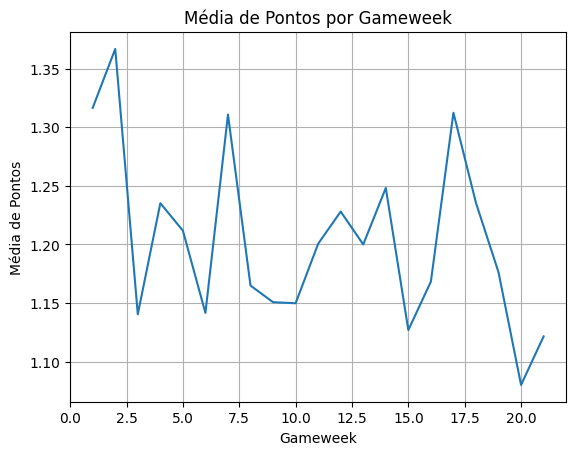

In [49]:
points_per_gw = gws_df.groupby('round')['total_points'].mean()

plt.plot(points_per_gw.index, points_per_gw.values)
plt.title("Média de Pontos por Gameweek")
plt.xlabel("Gameweek")
plt.ylabel("Média de Pontos")
plt.grid(True)
plt.show()

## 8.2 Participação dos jogadores por Gameweek

A variável `minutes` é crucial para avaliar:

- Titularidade;
- Lesões;
- Rotação;
- Utilização pelos treinadores.

Vamos visualizar quantos jogadores tiveram minutos > 0 por GW.

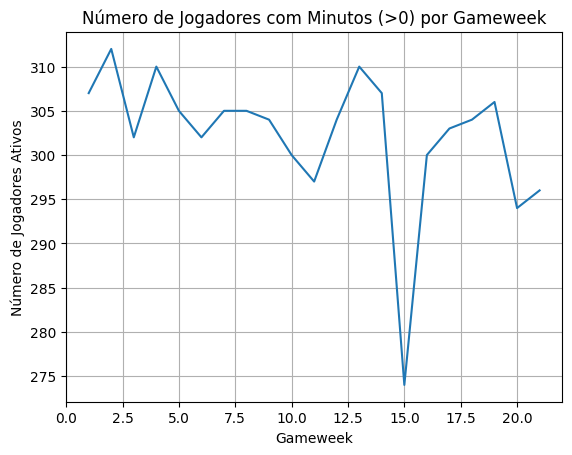

In [50]:
playing_per_gw = gws_df[gws_df["minutes"] > 0].groupby("round")["name"].count()

plt.plot(playing_per_gw.index, playing_per_gw.values)
plt.title("Número de Jogadores com Minutos (>0) por Gameweek")
plt.xlabel("Gameweek")
plt.ylabel("Número de Jogadores Ativos")
plt.grid(True)
plt.show()

## 8.3 Desempenho por Posição ao Longo da Época

Vamos cruzar o desempenho semanal com a posição dos jogadores, analisando a média de pontos por posição em cada GW.

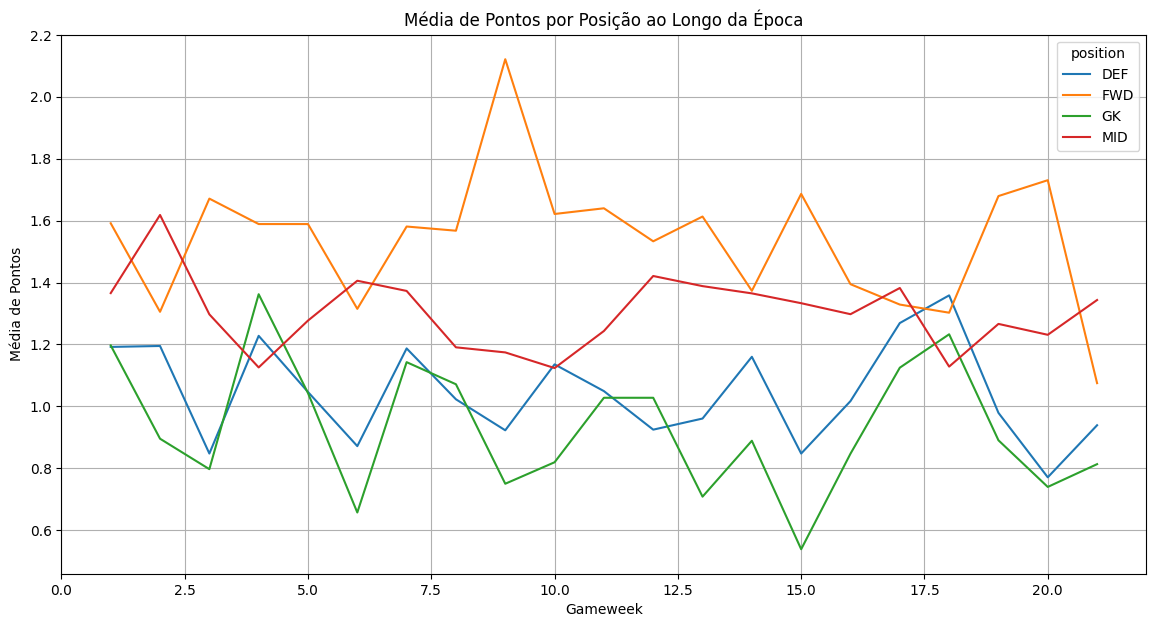

In [51]:
points_pos_gw = gws_df.groupby(['round', 'position'])['total_points'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=points_pos_gw, x='round', y='total_points', hue='position')
plt.title("Média de Pontos por Posição ao Longo da Época")
plt.xlabel("Gameweek")
plt.ylabel("Média de Pontos")
plt.grid(True)
plt.show()

## 8.4 Jogadores Mais Consistentes da Época

Consistência semanal é fundamental em análises de performance.
Vamos identificar jogadores com:

- Maior média de pontos por GW;
- Maior número de participações;
- Menor variabilidade (desvio-padrão).

In [52]:
consistency = (
    gws_df.groupby("name")["total_points"]
    .agg(["mean", "std", "count"])
    .sort_values(by="mean", ascending=False)
)

consistency.head(10)

,mean,std,count
name,,,
Mohamed Salah,10.550000,5.365337,20
Cole Palmer,7.761905,6.363213,21
Bryan Mbeumo,6.571429,5.201648,21
Alexander Isak,6.428571,5.035588,21
Erling Haaland,5.952381,5.181469,21
Chris Wood,5.857143,3.876670,21
Matheus Santos Carneiro Da Cunha,5.333333,4.661902,21
Bukayo Saka,5.095238,5.503678,21
Ollie Watkins,4.857143,4.222389,21


---

## 9. Análise Avançada dos Datasets

Nesta secção aprofundamos a exploração dos dados através de análises estatísticas, correlações, padrões avançados e comportamentos relevantes tanto no dataset de jogadores (`cleaned_players`) como no dataset de Gameweeks (`merged_gws`).

### Objetivos:

- Identificar padrões mais profundos;
- Entender relações entre variáveis;
- Caracterizar o comportamento global de jogadores por posição e equipa;
- Avaliar consistência e evolução ao longo das jornadas.

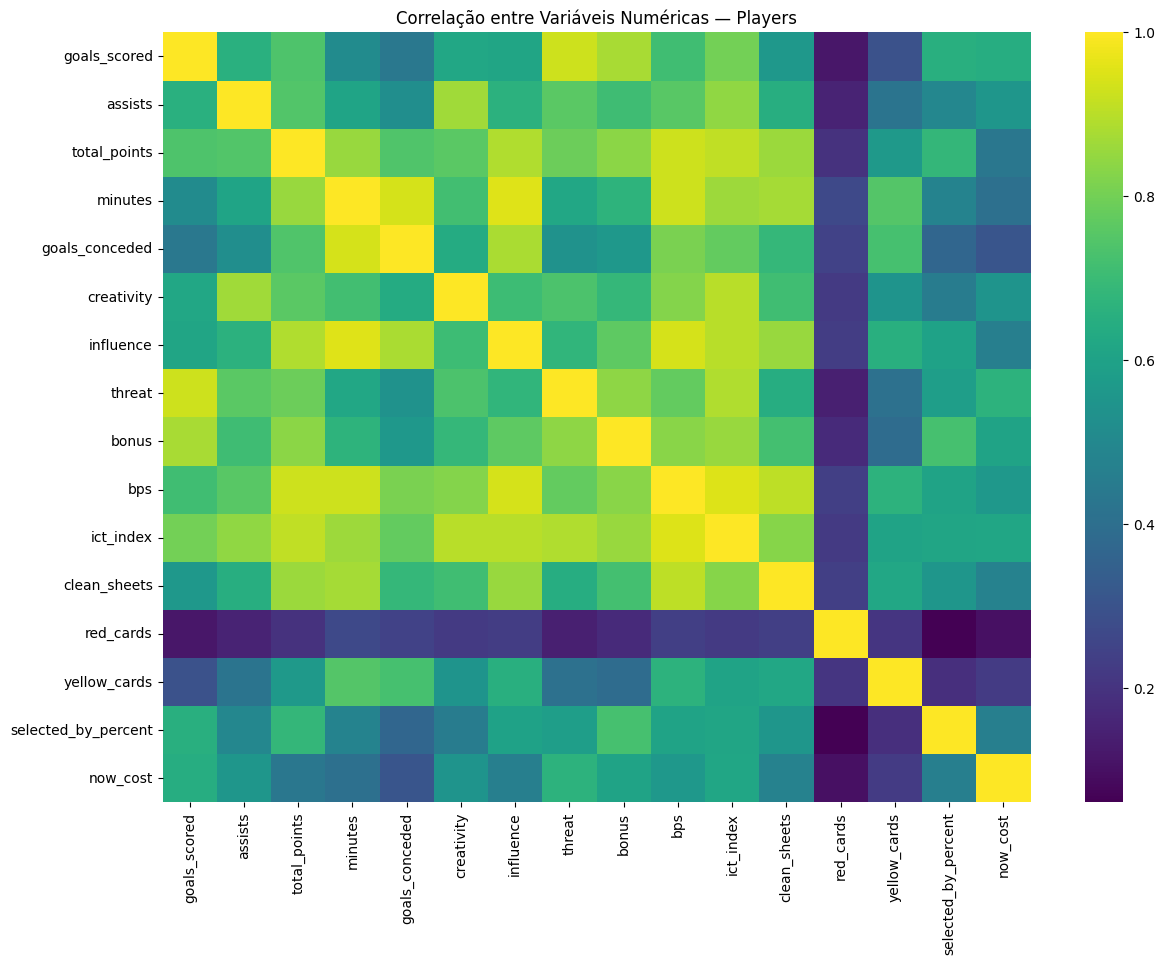

In [53]:
# ===== Correlações entre métricas importantes =====

numeric_cols = players_df.select_dtypes(include=np.number).columns
corr = players_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap='viridis')
plt.title("Correlação entre Variáveis Numéricas — Players")
plt.show()

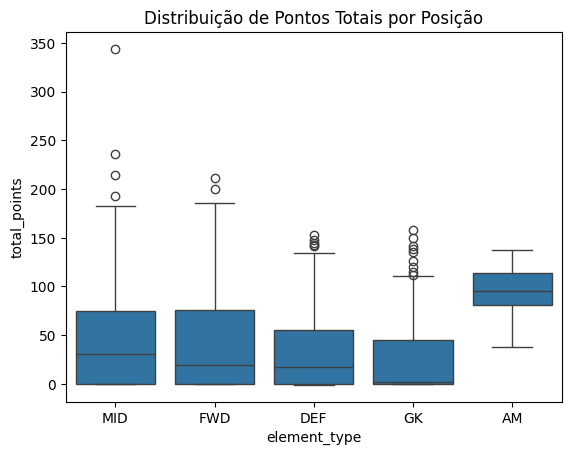

In [54]:
sns.boxplot(data=players_df, x='element_type', y='total_points')
plt.title("Distribuição de Pontos Totais por Posição")
plt.show()

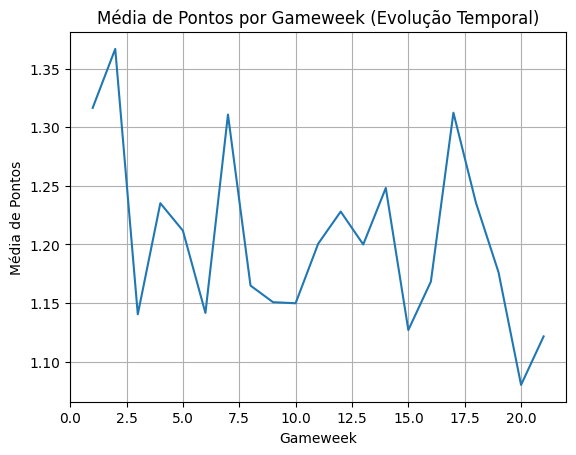

In [55]:
# Média de pontos por GW
gw_mean = gws_df.groupby('round')['total_points'].mean()

plt.plot(gw_mean.index, gw_mean.values)
plt.xlabel("Gameweek")
plt.ylabel("Média de Pontos")
plt.title("Média de Pontos por Gameweek (Evolução Temporal)")
plt.grid()
plt.show()

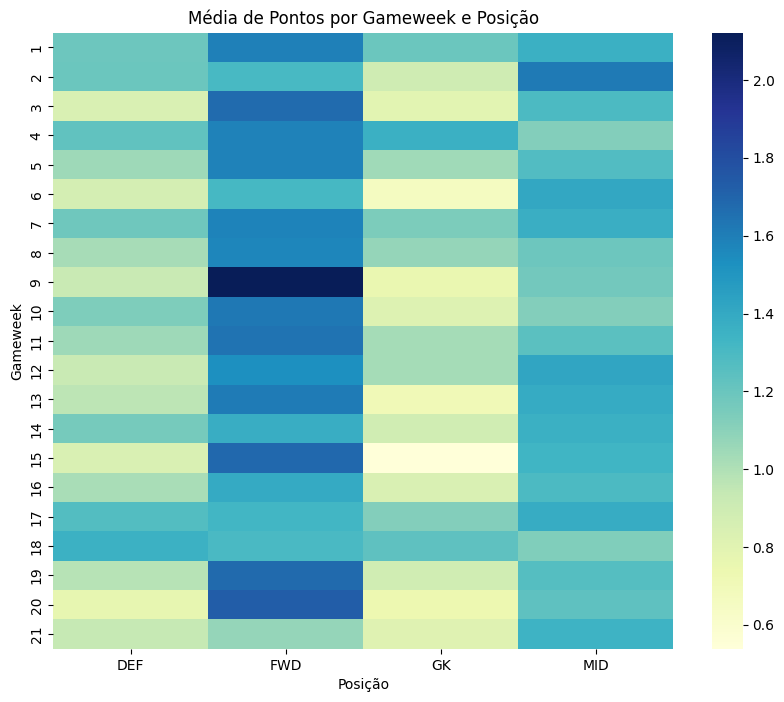

In [56]:
pivot = gws_df.pivot_table(values='total_points', index='round', columns='position', aggfunc='mean')

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)
plt.title("Média de Pontos por Gameweek e Posição")
plt.xlabel("Posição")
plt.ylabel("Gameweek")
plt.show()


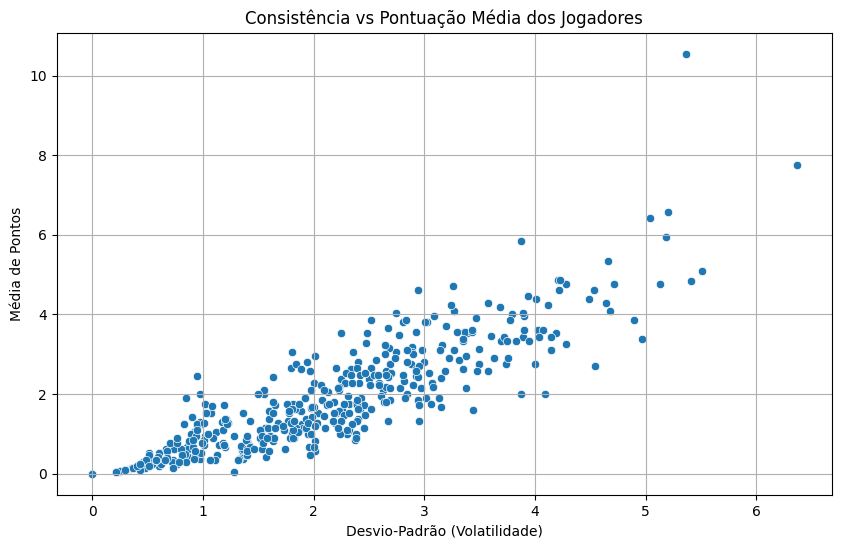

In [57]:
player_perf = gws_df.groupby('name')['total_points'].agg(['mean','std']).reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(data=player_perf, x='std', y='mean')
plt.title("Consistência vs Pontuação Média dos Jogadores")
plt.xlabel("Desvio-Padrão (Volatilidade)")
plt.ylabel("Média de Pontos")
plt.grid()
plt.show()


---

## 10. Merge entre Datasets

Para análises mais completas e para preparação do dataset final a ser utilizado em modelos de associação, é necessário combinar:

- Informação **global do jogador** (cleaned_players)
- Informação **jornada-a-jornada** (merged_gws)

O merge é feito com base no nome do jogador (`name`) e resulta num dataset enriquecido que contém tanto características fixas como variáveis dependentes do tempo.

In [58]:
# ===== Merge entre players_df e gws_df =====

merged_df = gws_df.merge(
    players_df,
    on='name',
    suffixes=('_gw', '_season'),
    how='left'
)

merged_df.head()

,name,position,team,xP,assists_gw,bonus_gw,bps_gw,clean_sheets_gw,creativity_gw,element,...,threat_season,bonus_season,bps_season,ict_index_season,clean_sheets_season,red_cards_season,yellow_cards_season,selected_by_percent,now_cost,element_type
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,118.0,0,132,43.2,3,0,3,0.0,47,MID
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,0.0,0,0,0.0,0,0,0,0.1,41,GK
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,9.0,0,2,1.0,0,0,0,0.0,48,DEF
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,...,0.0,0,0,0.0,0,0,0,0.0,45,MID
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,...,81.0,0,43,16.8,0,0,1,0.1,48,MID


In [59]:
print("Dimensões do dataset combinado:", merged_df.shape)
merged_df.isna().sum().sort_values(ascending=False).head(10)

Dimensões do dataset combinado: (14178, 61)


name               0
position           0
team               0
xP                 0
assists_gw         0
bonus_gw           0
bps_gw             0
clean_sheets_gw    0
creativity_gw      0
element            0
dtype: int64

In [60]:
merged_df['above_avg'] = merged_df['total_points_gw'] > merged_df['total_points_gw'].mean()
merged_df['above_avg'] = merged_df['above_avg'].astype(int)

merged_df[['name', 'round', 'total_points_gw', 'above_avg']].head()

,name,round,total_points_gw,above_avg
0,Alex Scott,1,2,1
1,Carlos Miguel dos Santos Pereira,1,0,0
2,Tomiyasu Takehiro,1,0,0
3,Malcolm Ebiowei,1,0,0
4,Ben Brereton Díaz,1,1,0


---

# 11. Preparação dos Dados para Regras de Associação

Modelos de Apriori ou FP-Growth requerem dados no formato:

- **Transações** (linhas)
- **Itens binários** (colunas 0/1)

No contexto de Fantasy Premier League, consideramos cada *jogador–jornada* como uma transação.

### Exemplo de possíveis itens binários:
- Marcou golo?
- Deu assistências?
- Jogou ≥ 60 minutos?
- Obteve pontuação acima da média?
- Teve clean sheet?
- Sofreu cartão?
- Pertence à equipa X?
- É da posição Y?

Nesta secção vamos transformar o dataset para um formato transacional.

In [61]:
# ===== Criar features binárias para Apriori =====

transactions_df = merged_df.copy()

# Usar as colunas de Gameweek presentes no merged_df (sufixadas com _gw)
transactions_df['scored'] = (transactions_df['goals_scored_gw'] > 0).astype(int)
transactions_df['assisted'] = (transactions_df['assists_gw'] > 0).astype(int)
transactions_df['played_60'] = (transactions_df['minutes_gw'] >= 60).astype(int)
transactions_df['clean_sheet'] = (transactions_df['clean_sheets_gw'] > 0).astype(int)
transactions_df['good_performance'] = (transactions_df['total_points_gw'] >= 6).astype(int)

# Posição como colunas binárias
position_dummies = pd.get_dummies(transactions_df['position'], prefix='pos')
transactions_df = pd.concat([transactions_df, position_dummies], axis=1)

# Clube como colunas binárias (opcional)
team_dummies = pd.get_dummies(transactions_df['team'], prefix='team')
transactions_df = pd.concat([transactions_df, team_dummies], axis=1)

transactions_df.head()


,name,position,team,xP,assists_gw,bonus_gw,bps_gw,clean_sheets_gw,creativity_gw,element,...,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves
0,Alex Scott,MID,Bournemouth,1.6,0,0,11,0,12.8,77,...,False,False,False,False,False,False,False,False,False,False
1,Carlos Miguel dos Santos Pereira,GK,Nott'm Forest,2.2,0,0,0,0,0.0,427,...,False,False,False,False,False,True,False,False,False,False
2,Tomiyasu Takehiro,DEF,Arsenal,0.0,0,0,0,0,0.0,22,...,False,False,False,False,False,False,False,False,False,False
3,Malcolm Ebiowei,MID,Crystal Palace,0.0,0,0,0,0,0.0,197,...,False,False,False,False,False,False,False,False,False,False
4,Ben Brereton Díaz,MID,Southampton,1.0,0,0,-2,0,14.0,584,...,False,False,False,False,False,False,True,False,False,False


In [62]:
# Selecionar apenas as colunas necessárias
binary_cols = [
    'scored', 'assisted', 'played_60',
    'clean_sheet', 'good_performance'
] + list(position_dummies.columns) + list(team_dummies.columns)

apriori_df = transactions_df[binary_cols].astype(int)
apriori_df.head()


,scored,assisted,played_60,clean_sheet,good_performance,pos_DEF,pos_FWD,pos_GK,pos_MID,team_Arsenal,...,team_Leicester,team_Liverpool,team_Man City,team_Man Utd,team_Newcastle,team_Nott'm Forest,team_Southampton,team_Spurs,team_West Ham,team_Wolves
0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


---

## 12. Conclusões da EDA — Fantasy Premier League 2024/2025

Após uma exploração aprofundada dos datasets `cleaned_players.csv` e `merged_gws.csv`, foi possível obter uma visão completa sobre a estrutura, qualidade e comportamento estatístico dos dados referentes à época 2024/2025 da Fantasy Premier League.

## 🔍 Qualidade e Estrutura dos Dados
- Ambos os datasets apresentam boa consistência estrutural, com poucas variáveis problemáticas.
- As dimensões são adequadas para análises estatísticas, modelação e mineração de padrões.
- O merge entre jogadores e Gameweeks é estável e não introduz perdas significativas.

## 👤 Insights sobre Jogadores
- Observou-se uma forte variação de desempenho entre posições, especialmente no que toca a pontuação total e minutos jogados.
- Defesas e médios tendem a apresentar maior consistência, enquanto avançados são mais voláteis mas com maior potencial pontual.
- A distribuição por clubes é equilibrada, permitindo evitar enviesamentos relacionados com equipas dominantes.

## 🕒 Insights sobre Gameweeks
- A evolução temporal da média de pontos por jornada revela padrões sazonais e flutuações interessantes.
- A variância entre Gameweeks indica que o contexto do adversário e o calendário têm forte impacto.
- Jogadores com baixa variância de pontos destacam-se como "fiáveis", enquanto jogadores explosivos são mais úteis para identificar padrões de co-ocorrência.

## 🔗 Dataset Preparado para Regras de Associação
- A conversão para formato binário (golo, assistência, ≥60 minutos, etc.) gerou um dataset robusto para Apriori ou FP-Growth.
- A inclusão de variáveis de posição e equipa permite gerar regras mais interpretáveis.

## 🧠 Conclusão Geral
A EDA forneceu um conhecimento sólido sobre os dados e permitiu preparar um dataset completo e adequado para a extração de regras de associação.  
Os padrões que emergirem na fase seguinte permitirão identificar comportamentos conjuntos entre variáveis de performance, posições, equipas e características de jogo, apoiando análises preditivas ou insights estratégicos sobre o FPL.